<a href="https://colab.research.google.com/github/JestinG20/property-sale-prices/blob/main/Advanced_Machine_Learning_Models_for_Predicting_Property_Sale_Prices_in_New_York_City.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imported necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb


In [2]:
# Loaded the dataset
file_name = "DOF__Summary_of_Neighborhood_Sales_by_Neighborhood_Citywide_by_Borough_20250501.csv"
df = pd.read_csv(file_name)

# Sample data
print("Sample data:")
print(df.head())


Sample data:
     BOROUGH   NEIGHBORHOOD           TYPE OF HOME  NUMBER OF SALES  \
0  MANHATTAN  ALPHABET CITY    01 ONE FAMILY HOMES                1   
1  MANHATTAN  ALPHABET CITY    02 TWO FAMILY HOMES                1   
2  MANHATTAN  ALPHABET CITY  03 THREE FAMILY HOMES                1   
3  MANHATTAN        CHELSEA    01 ONE FAMILY HOMES                2   
4  MANHATTAN        CHELSEA    02 TWO FAMILY HOMES                2   

   LOWEST SALE PRICE  AVERAGE SALE PRICE  MEDIAN SALE PRICE  \
0             593362            593362.0           593362.0   
1            1320000           1320000.0          1320000.0   
2             900000            900000.0           900000.0   
3             500000           2875000.0          2875000.0   
4            1306213           2603107.0          2603107.0   

   HIGHEST SALE PRICE  YEAR  
0              593362  2010  
1             1320000  2010  
2              900000  2010  
3             5250000  2010  
4             3900000  2010  



Missing values per column:
BOROUGH               0
NEIGHBORHOOD          1
TYPE OF HOME          0
NUMBER OF SALES       0
LOWEST SALE PRICE     0
AVERAGE SALE PRICE    0
MEDIAN SALE PRICE     0
HIGHEST SALE PRICE    0
YEAR                  0
dtype: int64


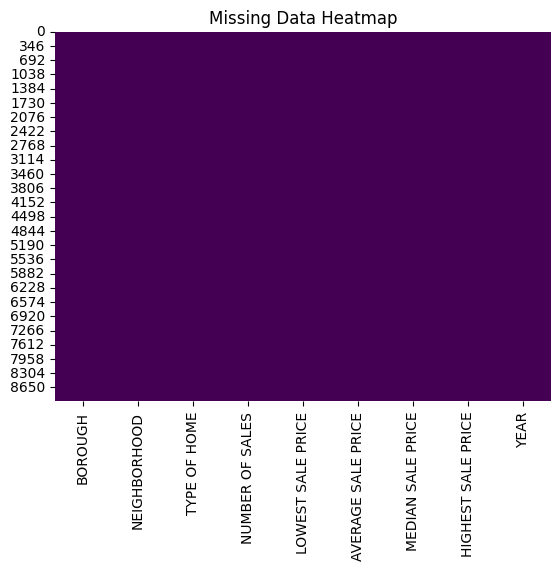

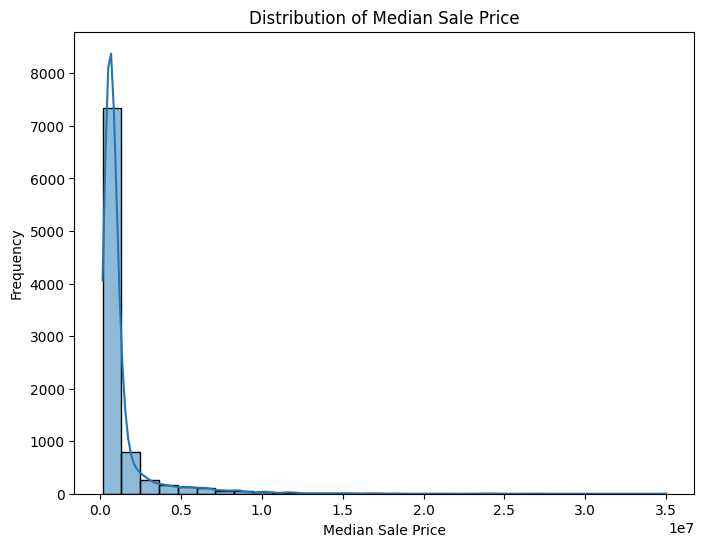

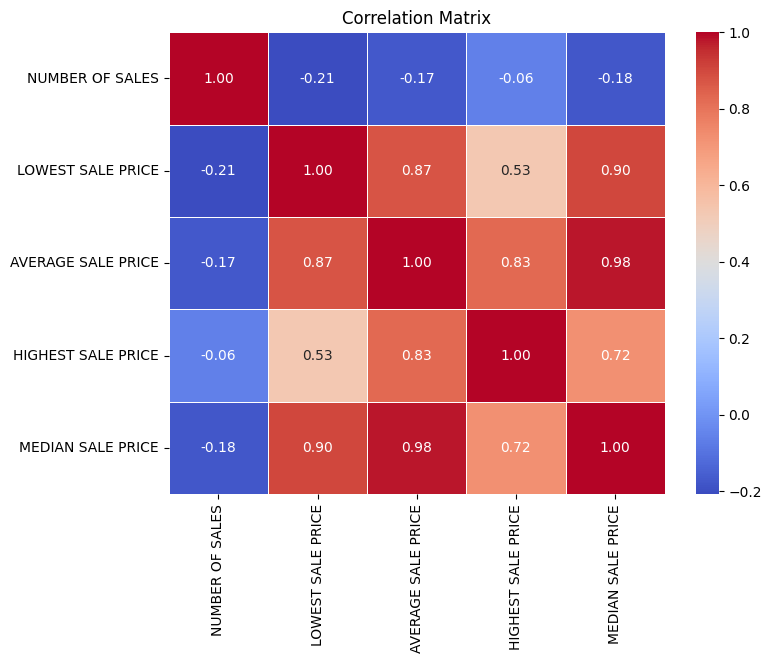

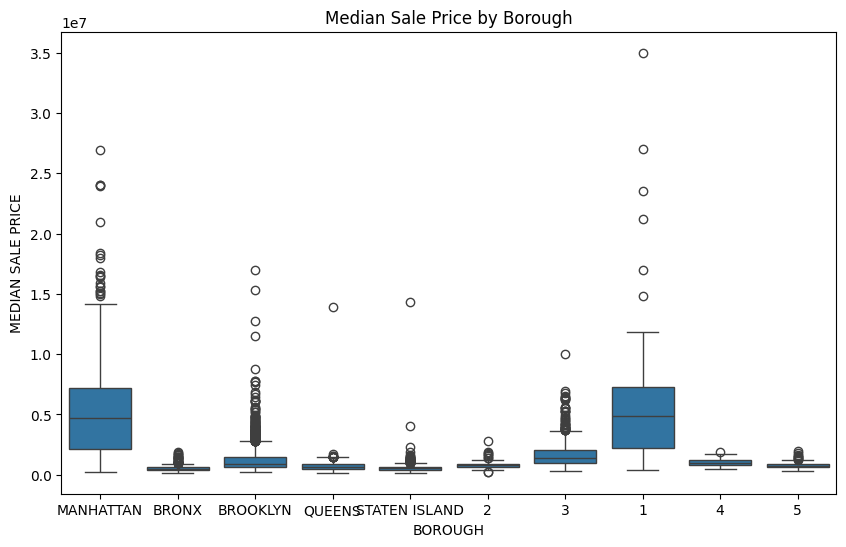

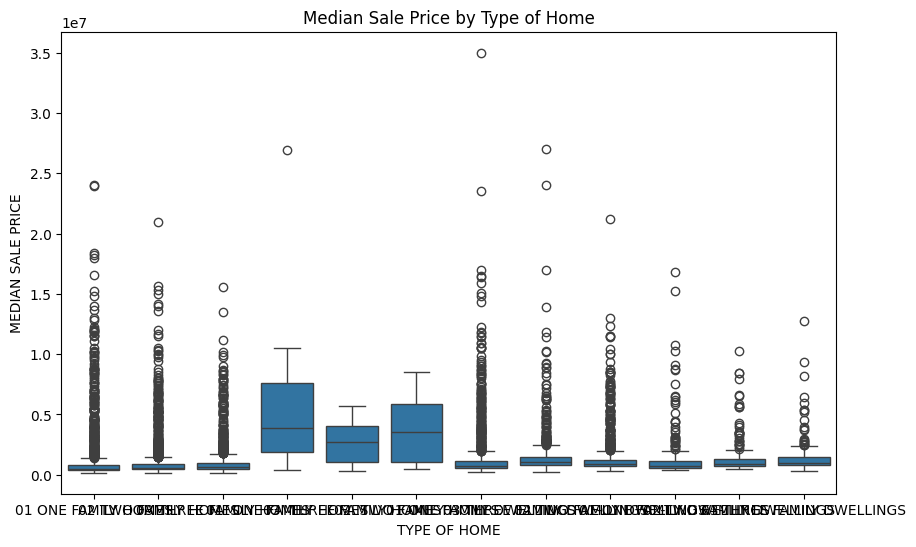

In [3]:
# Checked for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Visualized missing data (if any)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# Visualized the distribution of the target variable (MEDIAN SALE PRICE)
plt.figure(figsize=(8,6))
sns.histplot(df['MEDIAN SALE PRICE'], bins=30, kde=True)
plt.title('Distribution of Median Sale Price')
plt.xlabel('Median Sale Price')
plt.ylabel('Frequency')
plt.show()

# Correlation matrix for numerical features
num_cols = ['NUMBER OF SALES', 'LOWEST SALE PRICE', 'AVERAGE SALE PRICE', 'HIGHEST SALE PRICE', 'MEDIAN SALE PRICE']
correlation_matrix = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Boxplot for categorical variables and target (MEDIAN SALE PRICE)
plt.figure(figsize=(10,6))
sns.boxplot(x='BOROUGH', y='MEDIAN SALE PRICE', data=df)
plt.title('Median Sale Price by Borough')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='TYPE OF HOME', y='MEDIAN SALE PRICE', data=df)
plt.title('Median Sale Price by Type of Home')
plt.show()


In [4]:
# Feature Engineering

# Extracting year from the 'YEAR' column (if it's in string format)
df['YEAR'] = df['YEAR'].astype(int)

# Created new features
# Ratio of average sale price to highest sale price
df['AVG_TO_HIGHEST_PRICE_RATIO'] = df['AVERAGE SALE PRICE'] / df['HIGHEST SALE PRICE']

# Ratio of lowest sale price to highest sale price
df['LOWEST_TO_HIGHEST_PRICE_RATIO'] = df['LOWEST SALE PRICE'] / df['HIGHEST SALE PRICE']

# Encode categorical features
cat_cols = ['BOROUGH', 'NEIGHBORHOOD', 'TYPE OF HOME']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Defined features and target
features = ['BOROUGH', 'NEIGHBORHOOD', 'TYPE OF HOME', 'NUMBER OF SALES',
            'LOWEST SALE PRICE', 'AVERAGE SALE PRICE', 'HIGHEST SALE PRICE',
            'YEAR', 'AVG_TO_HIGHEST_PRICE_RATIO', 'LOWEST_TO_HIGHEST_PRICE_RATIO']
target = 'MEDIAN SALE PRICE'

X = df[features]
y = df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Defined models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression(),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Trained models and evaluated
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': model_name,
        'RMSE': rmse,
        'R² Score': r2
    })

# Created a DataFrame to compare the results
results_df = pd.DataFrame(results)

# Printed the results
print("\nModel Performance Comparison:")
print(results_df.sort_values(by='R² Score', ascending=False))

# Best model based on R² score
best_model = results_df.loc[results_df['R² Score'].idxmax()]

print(f"\nBest Model: {best_model['Model']}")


Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1808
[LightGBM] [Info] Number of data points in the train set: 7189, number of used features: 10
[LightGBM] [Info] Start training from score 1258827.183266
Training Linear Regression...
Training Gradient Boosting...

Model Performance Comparison:
               Model           RMSE  R² Score
0      Random Forest  266163.721340  0.982687
4  Gradient Boosting  272042.855992  0.981914
3  Linear Regression  303721.307356  0.977456
2           LightGBM  331255.448910  0.973184
1            XGBoost  332005.863194  0.973062

Best Model: Random Forest
